In [41]:
!pip install focal-loss

In [42]:
import tensorflow as tf
from tensorflow.keras import layers, applications, callbacks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from focal_loss import SparseCategoricalFocalLoss
import gc

In [43]:
SEED = 24520152

In [44]:
tf.keras.utils.set_random_seed(SEED)

In [45]:
TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [46]:
SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [47]:
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [48]:
model_name = 'ResNet50V2'
model_name

'ResNet50V2'

In [49]:
preprocess_fn = applications.resnet_v2.preprocess_input

In [50]:
def build_data_augmentation(SEED=24520152):
    """Create a simple data augmentation pipeline"""
    return tf.keras.Sequential([
        layers.RandomFlip('horizontal', seed=SEED),
        layers.RandomRotation(0.1, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
        layers.RandomContrast(0.1, seed=SEED),
        layers.RandomBrightness(0.1, seed=SEED),
    ], name='data_augmentation')

In [51]:
def get_data_for_fold(k, preprocess_fn, train_dir=TRAIN_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, SEED=24520152):
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]
    
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )
    
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dirs[0],
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )
    
    for directory in train_dirs[1:]:
        ds_part = tf.keras.utils.image_dataset_from_directory(
            directory,
            image_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
        )
        train_ds = train_ds.concatenate(ds_part)

    train_ds = train_ds.shuffle(buffer_size=3000, seed=SEED)
    
    AUTOTUNE = tf.data.AUTOTUNE
    data_augmentation = build_data_augmentation()

    def augment_and_preprocess_train(image, label):
        """Apply augmentation and preprocessing to the training set"""
        image = data_augmentation(image, training=True)
        image = preprocess_fn(image)
        return image, label

    def preprocess_val(image, label):
        """Apply preprocessing to the validation set (no augmentation)"""
        image = preprocess_fn(image)
        return image, label

    train_ds = train_ds.map(augment_and_preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.map(preprocess_val, num_parallel_calls=AUTOTUNE).prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds

In [52]:
def build_resnet50v2(INPUT_SHAPE=(224, 224, 3), NUM_CLASSES=3, DROPOUT_RATE=0.3):
    """
    Build a ResNet50V2 model with a custom head for classification
    This uses feature extraction (freezing the backbone)

    Args:
        INPUT_SHAPE (tuple): The shape of the input images
        NUM_CLASSES (int): The number of output classes
        DROPOUT_RATE (float): Dropout rate for the classifier head

    Returns:
        tf.keras.Model: The compiled Keras model
    """
    input_layer = tf.keras.Input(shape=INPUT_SHAPE, name="input_layer")

    backbone = applications.ResNet50V2(
        include_top=False,
        weights='imagenet',
    )
    backbone.trainable = False

    x = backbone(input_layer, training=False)
    x = layers.GlobalAveragePooling2D(name='pooling_layer')(x)
    x = layers.Dropout(DROPOUT_RATE, name='dropout_layer')(x)
    output_layer = layers.Dense(NUM_CLASSES, activation='softmax', name='output_layer')(x)

    model = tf.keras.Model(inputs=input_layer, outputs=output_layer, name=model_name)
    return model

In [53]:
def train_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50):
    # Build model
    model = build_resnet50v2()
    print(model.summary())

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    # Set up callbacks
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.keras')

    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    # Train model
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return history

In [54]:
def test_classifier(train_ds, val_ds, preprocess_fn, fold_k, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    # history = train_classifier(
    #     train_ds=train_ds,
    #     val_ds=val_ds,
    #     preprocess_fn=preprocess_fn,
    #     fold_k=fold_k,
    # )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_6_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    del model, results, loss, results_df, y_true, y_pred, cm
    tf.keras.backend.clear_session()
    gc.collect()

    return acc

In [55]:
def train_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, IMG_SIZE=(224, 224), BATCH_SIZE=32, EPOCHS=50, LEARNING_RATE=0.00001):
    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block + 1}_fold_{fold_k}.keras')
    print(model.summary())
    
    backbone = model.get_layer('resnet50v2')
    backbone.trainable = True
    
    set_trainable = False
    if block == 1:
        set_trainable = True
    for layer in backbone.layers:
        if layer.name == f'conv{block}_block1_1_conv':
            set_trainable = True
        if set_trainable:
            layer.trainable = True
        else:
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=SparseCategoricalFocalLoss(gamma=2.0),
        metrics=['accuracy'],
    )

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.keras')
    callback_list = [
        callbacks.ModelCheckpoint(
            filepath=checkpoint_path, 
            monitor='val_accuracy', 
            verbose=1, 
            save_best_only=True, 
            save_weights_only=False,
        ),
        callbacks.EarlyStopping(
            monitor='val_accuracy', 
            patience=6, 
            verbose=1, 
            restore_best_weights=True,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.2, 
            patience=3, 
            verbose=1, 
            min_lr=1e-7,
        )
    ]

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        verbose=1,
        callbacks=callback_list,
        validation_data=val_ds,
    )

    del model
    tf.keras.backend.clear_session()
    gc.collect()

    return history

In [56]:
def test_block(train_ds, val_ds, preprocess_fn, fold_k, block, save_dir=SAVE_DIR, class_names=CLASS_NAMES):
    # history = train_block(
    #     train_ds=train_ds,
    #     val_ds=val_ds,
    #     preprocess_fn=preprocess_fn,
    #     fold_k=fold_k,
    #     block=block,
    # )

    model = tf.keras.models.load_model(f'{SAVE_DIR}{model_name}_block_{block}_fold_{fold_k}.keras')
    results = []
    loss, acc = model.evaluate(val_ds, verbose=1)
    results.append({
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    print(results_df)

    y_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
    y_pred = np.argmax(model.predict(val_ds), axis=1)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    del model, results, loss, results_df, y_true, y_pred, cm
    tf.keras.backend.clear_session()
    gc.collect()

    return acc

In [57]:
acc_b6 = []
acc_b5 = []
acc_b4 = []
acc_b3 = []
acc_b2 = []
acc_b1 = []

Fold: 1 block 6
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.9300 - loss: 0.0635
        Model      Loss  Accuracy
0  ResNet50V2  0.087748  0.904059
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.95      0.94       245
Meningioma Tumor       0.86      0.71      0.78       112
 Pituitary Tumor       0.90      0.96      0.93       185

        accuracy                           0.90       542
       macro avg       0.89      0.87      0.88       542
    weighted avg       0.90      0.90      0.90       542



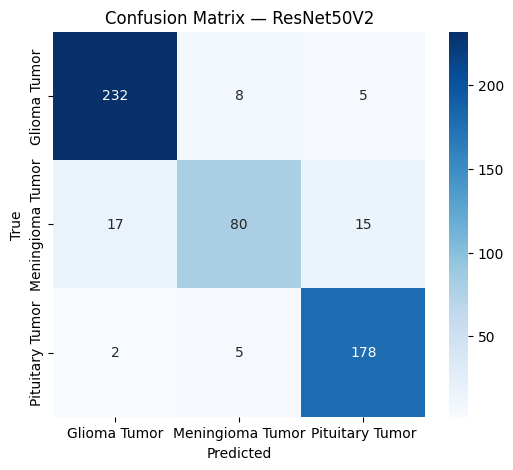

Fold: 1 block 5
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.9632 - loss: 0.0378
        Model      Loss  Accuracy
0  ResNet50V2  0.057633  0.940959
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 238ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       245
Meningioma Tumor       0.86      0.86      0.86       112
 Pituitary Tumor       0.96      0.95      0.95       185

        accuracy                           0.94       542
       macro avg       0.93      0.93      0.93       542
    weighted avg       0.94      0.94      0.94       542



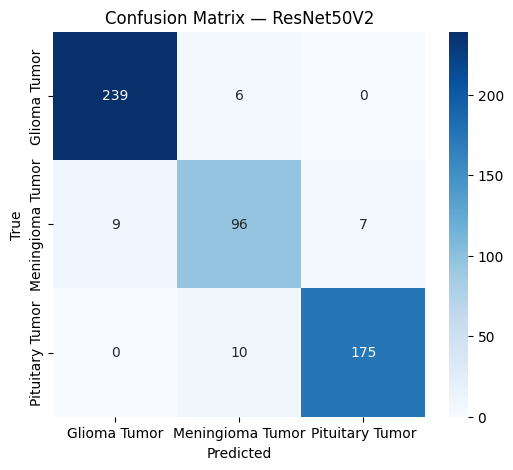

Fold: 1 block 4
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.9483 - loss: 0.0468
        Model    Loss  Accuracy
0  ResNet50V2  0.0596  0.940959
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 238ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.96      0.96       245
Meningioma Tumor       0.91      0.81      0.86       112
 Pituitary Tumor       0.92      0.99      0.96       185

        accuracy                           0.94       542
       macro avg       0.93      0.92      0.93       542
    weighted avg       0.94      0.94      0.94       542



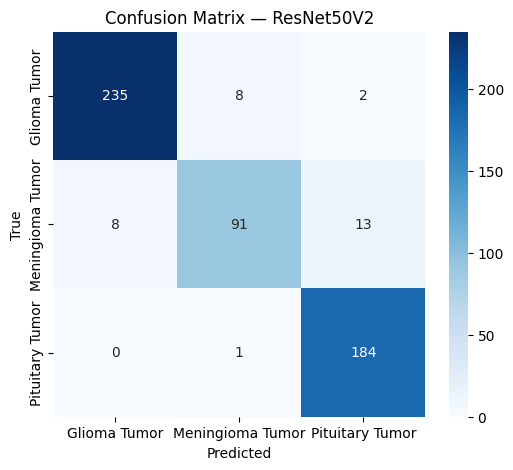

Fold: 1 block 3
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.9595 - loss: 0.0359
        Model      Loss  Accuracy
0  ResNet50V2  0.049921  0.948339
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.96      0.96       245
Meningioma Tumor       0.91      0.86      0.88       112
 Pituitary Tumor       0.97      0.99      0.98       185

        accuracy                           0.95       542
       macro avg       0.94      0.94      0.94       542
    weighted avg       0.95      0.95      0.95       542



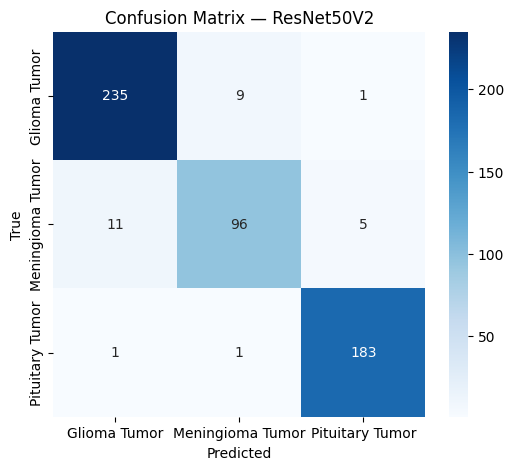

Fold: 1 block 2
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.9672 - loss: 0.0248
        Model      Loss  Accuracy
0  ResNet50V2  0.035415   0.95941
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.96      0.97       245
Meningioma Tumor       0.88      0.94      0.91       112
 Pituitary Tumor       0.98      0.97      0.98       185

        accuracy                           0.96       542
       macro avg       0.95      0.96      0.95       542
    weighted avg       0.96      0.96      0.96       542



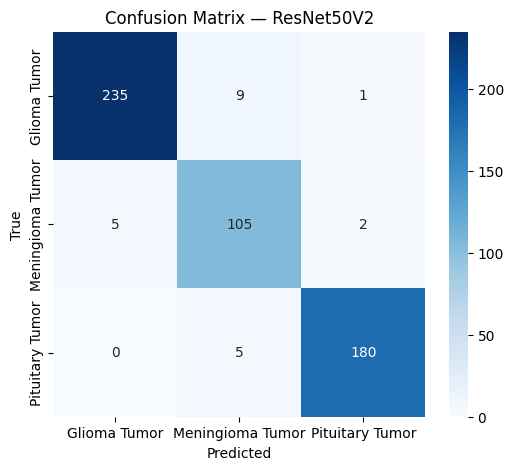

Fold: 1 block 1
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.9671 - loss: 0.0311
        Model      Loss  Accuracy
0  ResNet50V2  0.042384   0.95572
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 249ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       245
Meningioma Tumor       0.90      0.89      0.90       112
 Pituitary Tumor       0.98      0.96      0.97       185

        accuracy                           0.96       542
       macro avg       0.95      0.94      0.95       542
    weighted avg       0.96      0.96      0.96       542



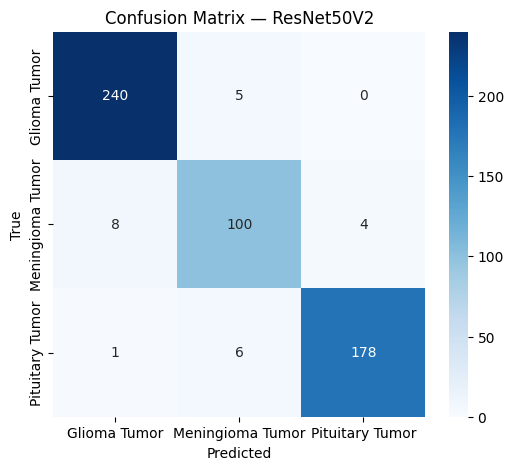

Fold: 2 block 6
Found 679 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.8936 - loss: 0.1014
        Model      Loss  Accuracy
0  ResNet50V2  0.134464  0.851252
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.91      0.89       338
Meningioma Tumor       0.78      0.67      0.72       167
 Pituitary Tumor       0.87      0.91      0.89       174

        accuracy                           0.85       679
       macro avg       0.84      0.83      0.83       679
    weighted avg       0.85      0.85      0.85       679



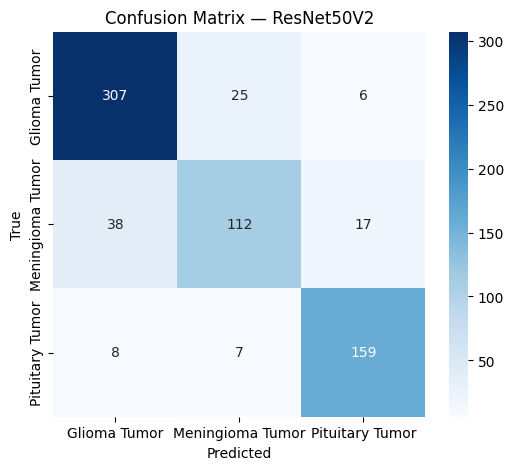

Fold: 2 block 5
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9122 - loss: 0.1019
        Model      Loss  Accuracy
0  ResNet50V2  0.134555  0.886598
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.89      0.93      0.91       338
Meningioma Tumor       0.87      0.74      0.80       167
 Pituitary Tumor       0.90      0.94      0.92       174

        accuracy                           0.89       679
       macro avg       0.88      0.87      0.88       679
    weighted avg       0.89      0.89      0.88       679



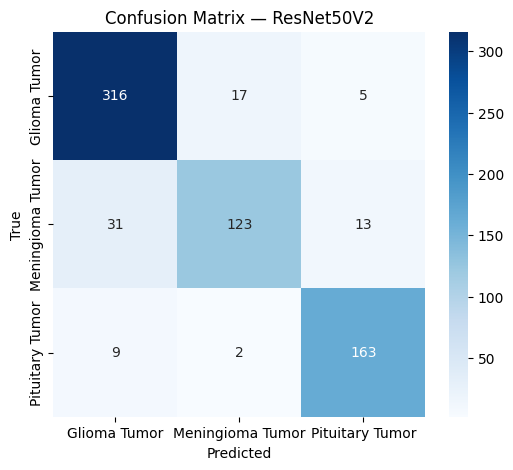

Fold: 2 block 4
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.9004 - loss: 0.1337
        Model      Loss  Accuracy
0  ResNet50V2  0.146032  0.888071
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.92      0.91       338
Meningioma Tumor       0.86      0.72      0.79       167
 Pituitary Tumor       0.88      0.99      0.93       174

        accuracy                           0.89       679
       macro avg       0.88      0.88      0.88       679
    weighted avg       0.89      0.89      0.89       679



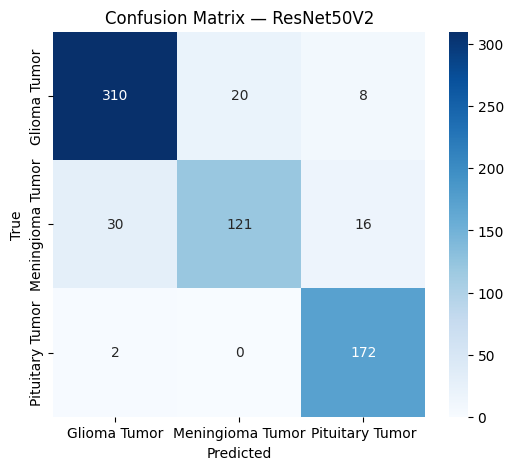

Fold: 2 block 3
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.9108 - loss: 0.1432
        Model      Loss  Accuracy
0  ResNet50V2  0.158792   0.89838
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.93      0.93       338
Meningioma Tumor       0.87      0.75      0.80       167
 Pituitary Tumor       0.87      0.98      0.92       174

        accuracy                           0.90       679
       macro avg       0.89      0.89      0.88       679
    weighted avg       0.90      0.90      0.90       679



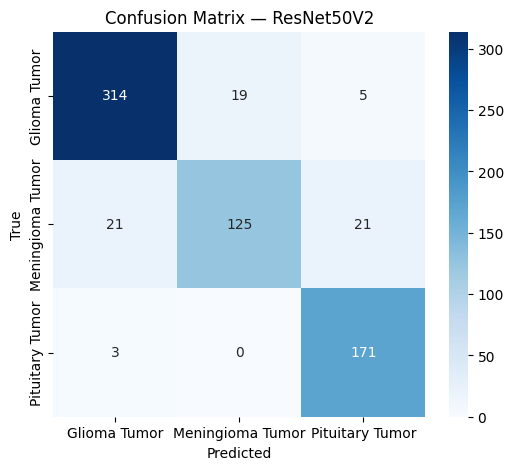

Fold: 2 block 2
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.9203 - loss: 0.1283
        Model      Loss  Accuracy
0  ResNet50V2  0.147188  0.904271
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 191ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.93      0.93       338
Meningioma Tumor       0.90      0.77      0.83       167
 Pituitary Tumor       0.86      0.98      0.91       174

        accuracy                           0.90       679
       macro avg       0.90      0.89      0.89       679
    weighted avg       0.91      0.90      0.90       679



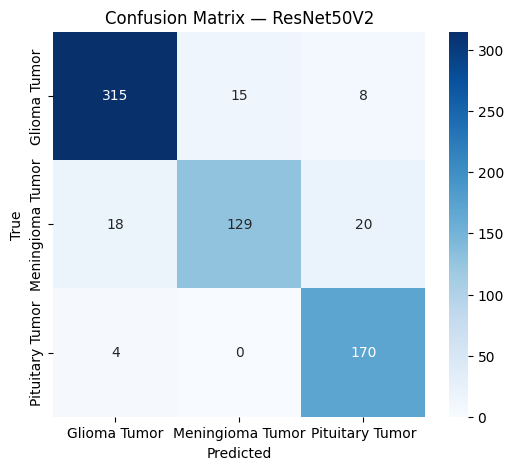

Fold: 2 block 1
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.9298 - loss: 0.0930
        Model      Loss  Accuracy
0  ResNet50V2  0.144411  0.893962
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.87      0.96      0.91       338
Meningioma Tumor       0.90      0.73      0.81       167
 Pituitary Tumor       0.94      0.93      0.93       174

        accuracy                           0.89       679
       macro avg       0.90      0.87      0.88       679
    weighted avg       0.90      0.89      0.89       679



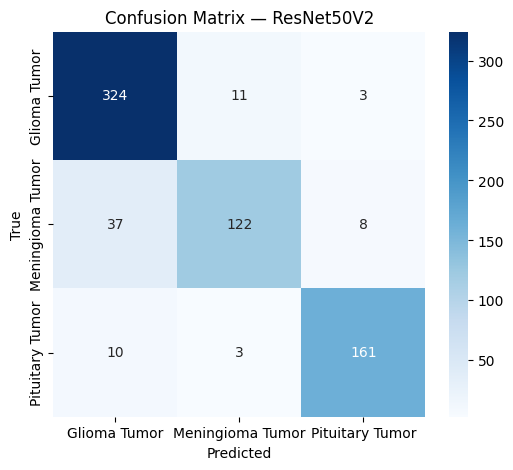

Fold: 3 block 6
Found 572 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.8927 - loss: 0.1121
        Model      Loss  Accuracy
0  ResNet50V2  0.124632  0.877622
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.86      0.88       231
Meningioma Tumor       0.78      0.75      0.76       139
 Pituitary Tumor       0.92      0.99      0.95       202

        accuracy                           0.88       572
       macro avg       0.86      0.86      0.86       572
    weighted avg       0.88      0.88      0.88       572



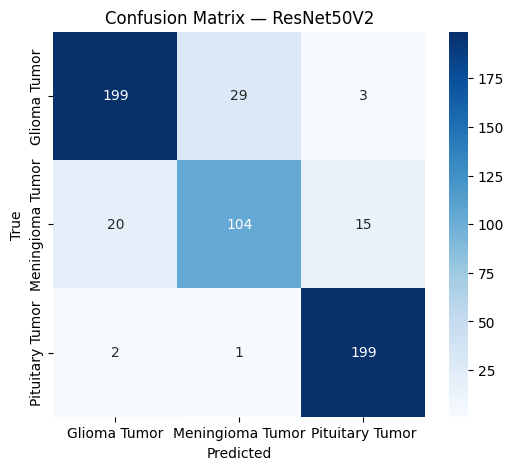

Fold: 3 block 5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.9015 - loss: 0.1068
        Model    Loss  Accuracy
0  ResNet50V2  0.1198  0.896853
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.87      0.90       231
Meningioma Tumor       0.79      0.81      0.80       139
 Pituitary Tumor       0.93      0.99      0.96       202

        accuracy                           0.90       572
       macro avg       0.88      0.89      0.89       572
    weighted avg       0.90      0.90      0.90       572



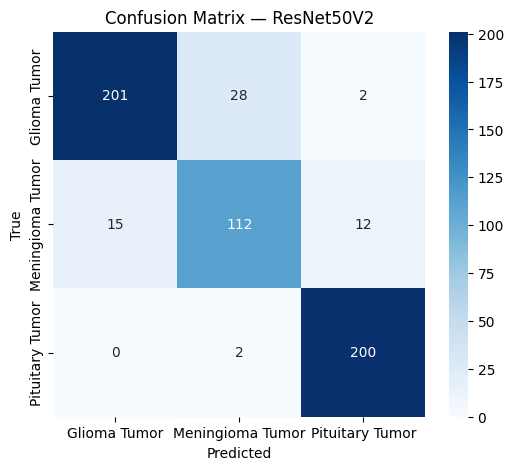

Fold: 3 block 4
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.9182 - loss: 0.1252
        Model      Loss  Accuracy
0  ResNet50V2  0.136953  0.905594
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.90      0.91       231
Meningioma Tumor       0.82      0.81      0.81       139
 Pituitary Tumor       0.93      0.98      0.96       202

        accuracy                           0.91       572
       macro avg       0.90      0.90      0.90       572
    weighted avg       0.90      0.91      0.90       572



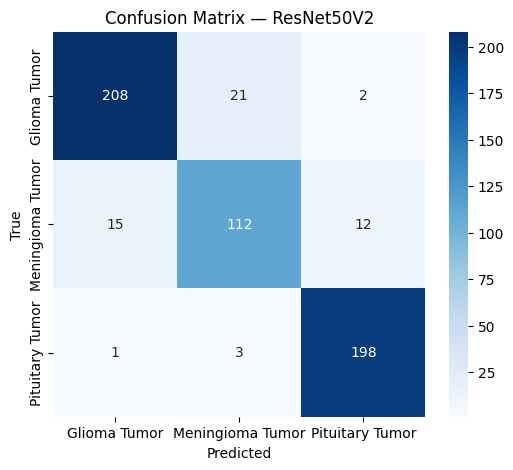

Fold: 3 block 3
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.9234 - loss: 0.1361
        Model      Loss  Accuracy
0  ResNet50V2  0.141818   0.91958
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.89      0.93       231
Meningioma Tumor       0.84      0.86      0.85       139
 Pituitary Tumor       0.93      1.00      0.96       202

        accuracy                           0.92       572
       macro avg       0.91      0.92      0.91       572
    weighted avg       0.92      0.92      0.92       572



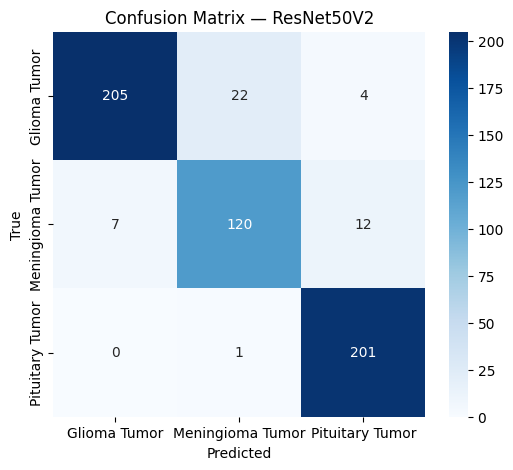

Fold: 3 block 2
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.9246 - loss: 0.1094
        Model      Loss  Accuracy
0  ResNet50V2  0.125515  0.907343
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 234ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.91      0.92       231
Meningioma Tumor       0.85      0.81      0.83       139
 Pituitary Tumor       0.93      0.97      0.95       202

        accuracy                           0.91       572
       macro avg       0.90      0.90      0.90       572
    weighted avg       0.91      0.91      0.91       572



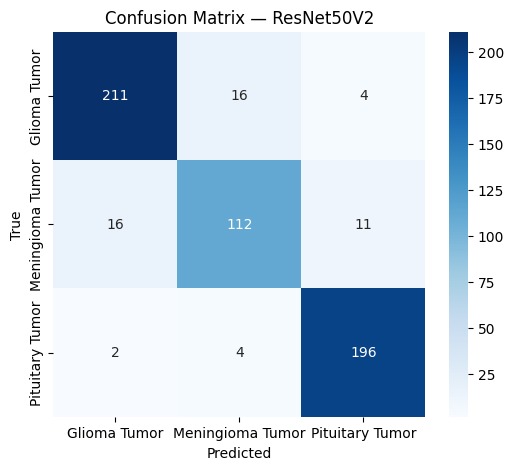

Fold: 3 block 1
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.9420 - loss: 0.0726
        Model      Loss  Accuracy
0  ResNet50V2  0.083462   0.93007
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.94      0.93       231
Meningioma Tumor       0.90      0.83      0.86       139
 Pituitary Tumor       0.98      0.99      0.98       202

        accuracy                           0.93       572
       macro avg       0.93      0.92      0.92       572
    weighted avg       0.93      0.93      0.93       572



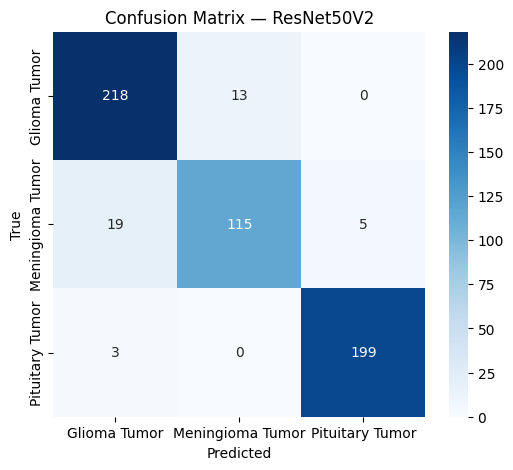

Fold: 4 block 6
Found 628 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 643 files belonging to 3 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.9466 - loss: 0.0566
        Model      Loss  Accuracy
0  ResNet50V2  0.080257  0.914013
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.96      0.95       325
Meningioma Tumor       0.84      0.76      0.80       124
 Pituitary Tumor       0.92      0.94      0.93       179

        accuracy                           0.91       628
       macro avg       0.90      0.89      0.89       628
    weighted avg       0.91      0.91      0.91       628



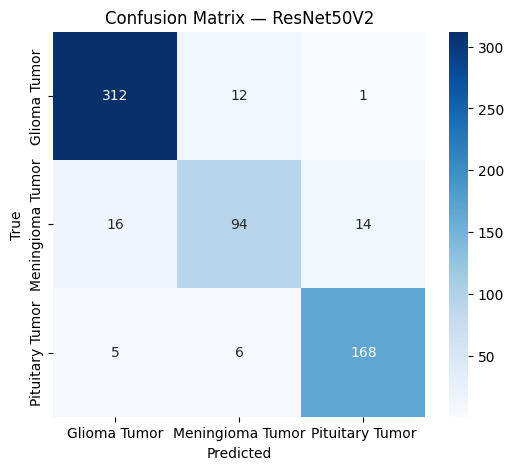

Fold: 4 block 5
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.9423 - loss: 0.0544
        Model      Loss  Accuracy
0  ResNet50V2  0.074215  0.929936
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.96      0.97       325
Meningioma Tumor       0.87      0.78      0.82       124
 Pituitary Tumor       0.90      0.97      0.93       179

        accuracy                           0.93       628
       macro avg       0.91      0.91      0.91       628
    weighted avg       0.93      0.93      0.93       628



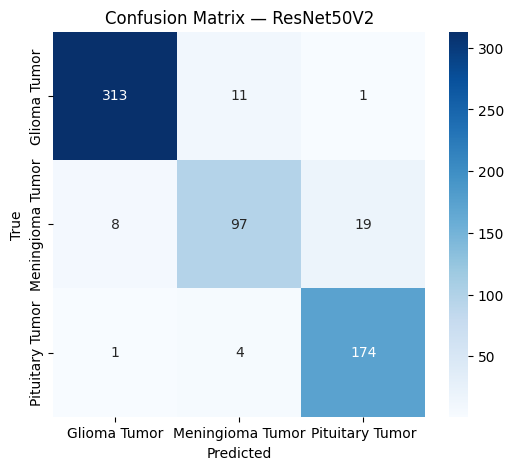

Fold: 4 block 4
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9459 - loss: 0.0481
        Model      Loss  Accuracy
0  ResNet50V2  0.081728  0.920382
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.97      0.97       325
Meningioma Tumor       0.87      0.72      0.79       124
 Pituitary Tumor       0.87      0.97      0.92       179

        accuracy                           0.92       628
       macro avg       0.90      0.89      0.89       628
    weighted avg       0.92      0.92      0.92       628



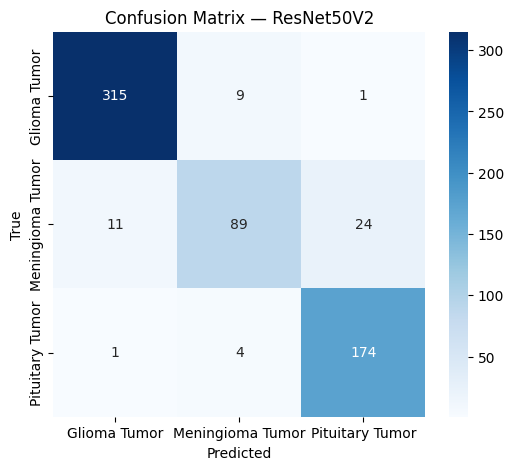

Fold: 4 block 3
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.9573 - loss: 0.0505
        Model      Loss  Accuracy
0  ResNet50V2  0.083228  0.928344
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       325
Meningioma Tumor       0.90      0.73      0.81       124
 Pituitary Tumor       0.88      0.97      0.92       179

        accuracy                           0.93       628
       macro avg       0.92      0.89      0.90       628
    weighted avg       0.93      0.93      0.93       628



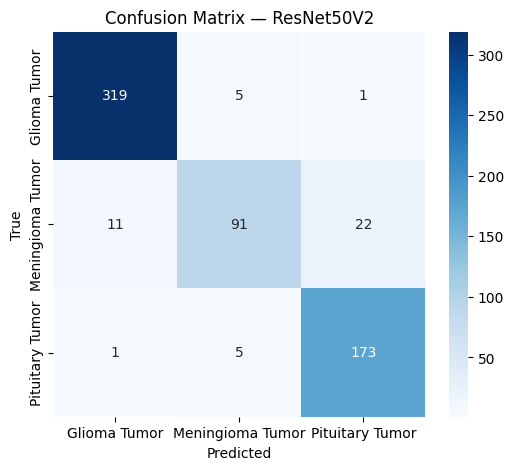

Fold: 4 block 2
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - accuracy: 0.9446 - loss: 0.0592
        Model      Loss  Accuracy
0  ResNet50V2  0.101004   0.91242
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.98      0.95       325
Meningioma Tumor       0.88      0.68      0.76       124
 Pituitary Tumor       0.90      0.96      0.93       179

        accuracy                           0.91       628
       macro avg       0.90      0.87      0.88       628
    weighted avg       0.91      0.91      0.91       628



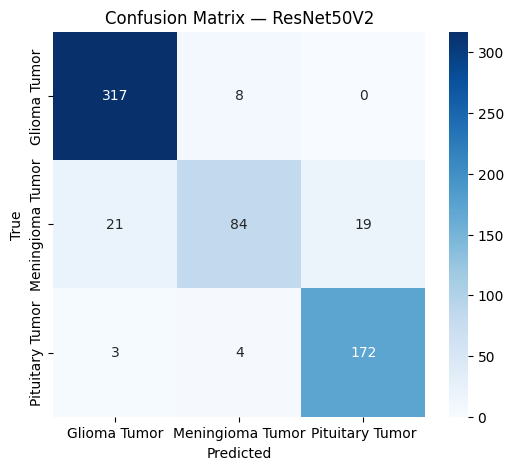

Fold: 4 block 1
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 122ms/step - accuracy: 0.9591 - loss: 0.0409
        Model      Loss  Accuracy
0  ResNet50V2  0.081185  0.929936
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.98      0.95       325
Meningioma Tumor       0.89      0.78      0.83       124
 Pituitary Tumor       0.97      0.94      0.95       179

        accuracy                           0.93       628
       macro avg       0.93      0.90      0.91       628
    weighted avg       0.93      0.93      0.93       628



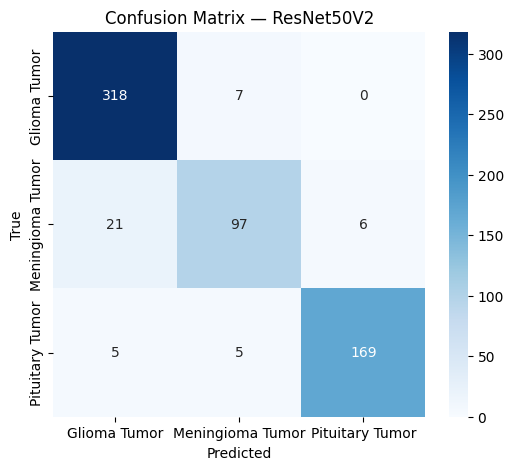

Fold: 5 block 6
Found 643 files belonging to 3 classes.
Found 542 files belonging to 3 classes.
Found 679 files belonging to 3 classes.
Found 572 files belonging to 3 classes.
Found 628 files belonging to 3 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.8054 - loss: 0.2447
        Model      Loss  Accuracy
0  ResNet50V2  0.249023  0.816485
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 208ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.91      0.83      0.86       287
Meningioma Tumor       0.68      0.62      0.65       166
 Pituitary Tumor       0.80      0.97      0.88       190

        accuracy                           0.82       643
       macro avg       0.80      0.81      0.80       643
    weighted avg       0.82      0.82      0.81       643



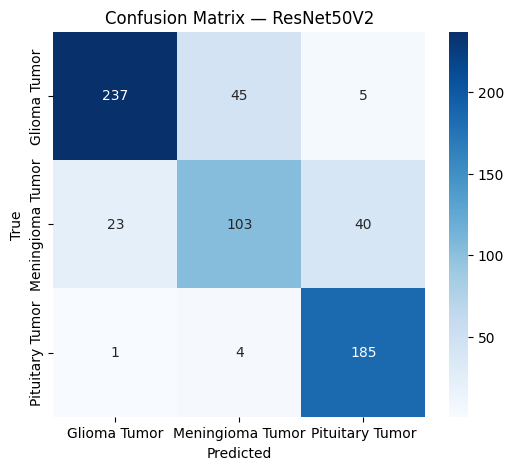

Fold: 5 block 5
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.8665 - loss: 0.1819
        Model      Loss  Accuracy
0  ResNet50V2  0.224395  0.860031
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.89      0.91       287
Meningioma Tumor       0.78      0.66      0.71       166
 Pituitary Tumor       0.84      0.99      0.91       190

        accuracy                           0.86       643
       macro avg       0.84      0.85      0.84       643
    weighted avg       0.86      0.86      0.86       643



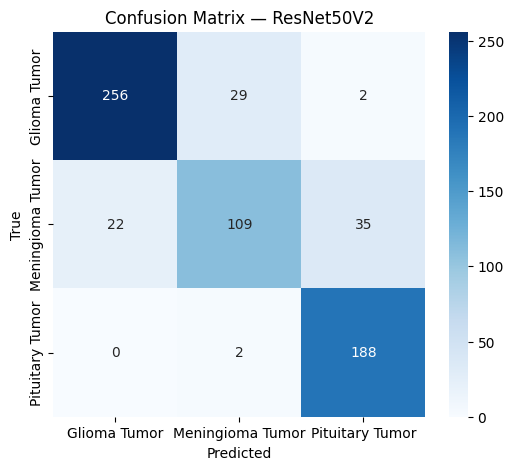

Fold: 5 block 4
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.8644 - loss: 0.2455
        Model      Loss  Accuracy
0  ResNet50V2  0.315751  0.858476
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.93      0.91      0.92       287
Meningioma Tumor       0.84      0.62      0.71       166
 Pituitary Tumor       0.78      0.99      0.87       190

        accuracy                           0.86       643
       macro avg       0.85      0.84      0.84       643
    weighted avg       0.86      0.86      0.85       643



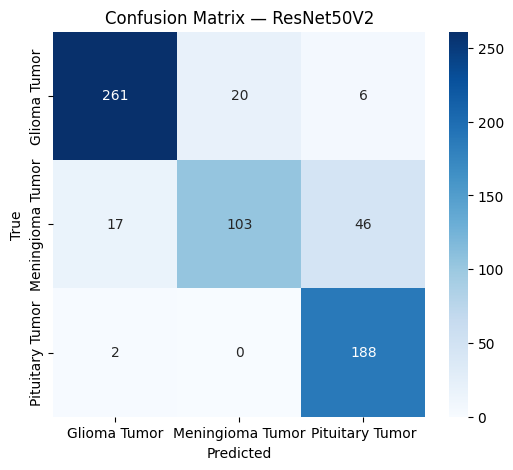

Fold: 5 block 3
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.8888 - loss: 0.2501
        Model      Loss  Accuracy
0  ResNet50V2  0.296182  0.883359
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.92      0.93       287
Meningioma Tumor       0.86      0.68      0.76       166
 Pituitary Tumor       0.82      1.00      0.90       190

        accuracy                           0.88       643
       macro avg       0.88      0.87      0.87       643
    weighted avg       0.89      0.88      0.88       643



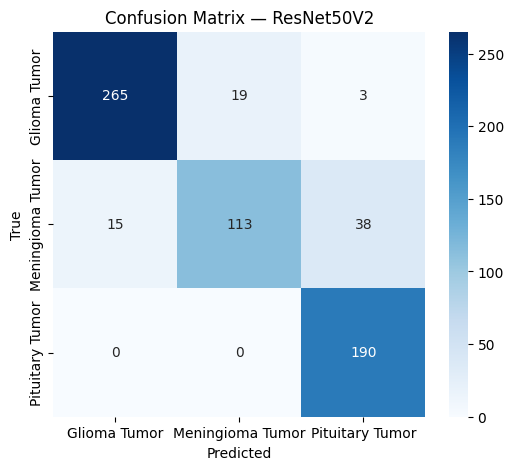

Fold: 5 block 2
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.8909 - loss: 0.2292
        Model     Loss  Accuracy
0  ResNet50V2  0.26605  0.884914
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.91      0.93       287
Meningioma Tumor       0.83      0.72      0.77       166
 Pituitary Tumor       0.83      0.99      0.90       190

        accuracy                           0.88       643
       macro avg       0.87      0.87      0.87       643
    weighted avg       0.89      0.88      0.88       643



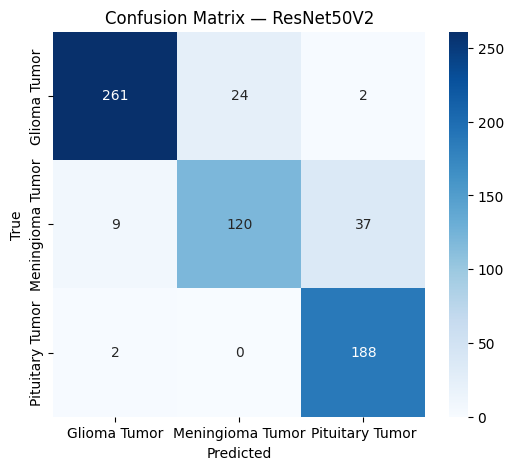

Fold: 5 block 1
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.8872 - loss: 0.1962
        Model      Loss  Accuracy
0  ResNet50V2  0.218519  0.884914
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 191ms/step
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.92      0.93       287
Meningioma Tumor       0.83      0.73      0.78       166
 Pituitary Tumor       0.86      0.97      0.91       190

        accuracy                           0.88       643
       macro avg       0.87      0.87      0.87       643
    weighted avg       0.88      0.88      0.88       643



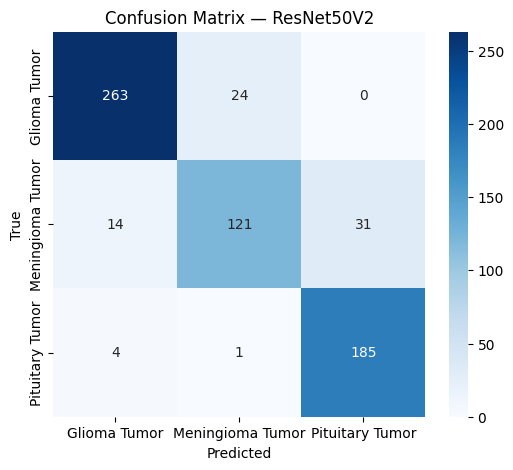

In [58]:
for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_ds, val_ds = get_data_for_fold(fold_k, preprocess_fn)
    
    acc_b6.append(test_classifier(train_ds, val_ds, preprocess_fn, fold_k))
    tf.keras.backend.clear_session()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_ds, val_ds, preprocess_fn, fold_k, block))
        tf.keras.backend.clear_session()
        gc.collect()
    
    del train_ds, val_ds
    gc.collect()

In [59]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]
ACC_BLOCK

[[0.9040590524673462,
  0.8512518405914307,
  0.8776223659515381,
  0.9140127301216125,
  0.8164852261543274],
 [0.9409593939781189,
  0.8865979313850403,
  0.8968531489372253,
  0.9299362897872925,
  0.8600311279296875],
 [0.9409593939781189,
  0.8880707025527954,
  0.9055944085121155,
  0.9203821420669556,
  0.858475923538208],
 [0.9483394622802734,
  0.8983799815177917,
  0.9195803999900818,
  0.9283439517021179,
  0.8833592534065247],
 [0.9594095945358276,
  0.9042710065841675,
  0.9073426723480225,
  0.912420392036438,
  0.8849144577980042],
 [0.955719530582428,
  0.8939617276191711,
  0.9300699234008789,
  0.9299362897872925,
  0.8849144577980042]]

In [60]:
for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 87.27%
Accuracy unfreeze block 5 - block 6: 90.29%
Accuracy unfreeze block 4 - block 6: 90.27%
Accuracy unfreeze block 3 - block 6: 91.56%
Accuracy unfreeze block 2 - block 6: 91.37%
Accuracy unfreeze block 1 - block 6: 91.89%
